# Illustrative full 2D and pseudo-3D diagrams

The following examples are intended to be illustrative of a full drawing.
If you supply a dict of `presets` to `Drawing`, then you can provide default
styling for various elements simply by name.

## 2D example

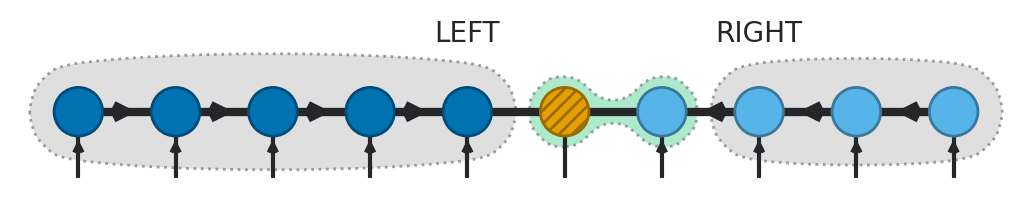

In [1]:
%config InlineBackend.figure_formats = ['retina']
import robodraw

presets = {
    "bond": {"linewidth": 3},
    "phys": {"linewidth": 1.5},
    "center": {
        # `get_color` uses more colorblind friendly colors
        "color": robodraw.get_color("orange"),
        "hatch": "/////",
    },
    "left": {
        "color": robodraw.get_color("bluedark"),
    },
    "right": {
        "color": robodraw.get_color("blue"),
    },
}

d = robodraw.Drawing(presets=presets)

L = 10
center = 5

for i in range(10):
    # draw tensor
    d.circle(
        (i, 0),
        preset=(
            "center" if i == center else "left" if i < center else "right"
        ),
    )

    # draw physical index
    d.line((i, 0), (i, -2 / 3), preset="phys")

    # draw virtual bond
    if i + 1 < L:
        d.line((i, 0), (i + 1, 0), preset="bond")

    # draw isometric conditions
    if i != center:
        d.arrowhead((i, -2 / 3), (i, 0), preset="phys")
    if i < center - 1:
        d.arrowhead((i, 0), (i + 1, 0), preset="bond")
    if i > center + 1:
        d.arrowhead((i, 0), (i - 1, 0), preset="bond")

# label the left
if center > 0:
    d.text((center - 1, 0.8), "LEFT")
    d.patch_around([(i, 0) for i in range(center)], radius=0.5)

# label pair
if center + 1 < L:
    d.patch_around_circles(
        (center, 0),
        0.3,
        (center + 1, 0),
        0.3,
        facecolor=(0.2, 0.8, 0.5, 0.4),
    )

# label the right
if center + 2 < L:
    d.text((center + 2, 0.8), "RIGHT")
    d.patch_around([(i, 0) for i in range(center + 2, L)], radius=0.5)

### Pseudo-3D example

If you supply 3D coordinates to `Drawing` methods then the objects will be
mapped by the axonometric projection to 2D and given appropriate z-ordering.
The projection and orientation can be controlled in the `Drawing` constructor.

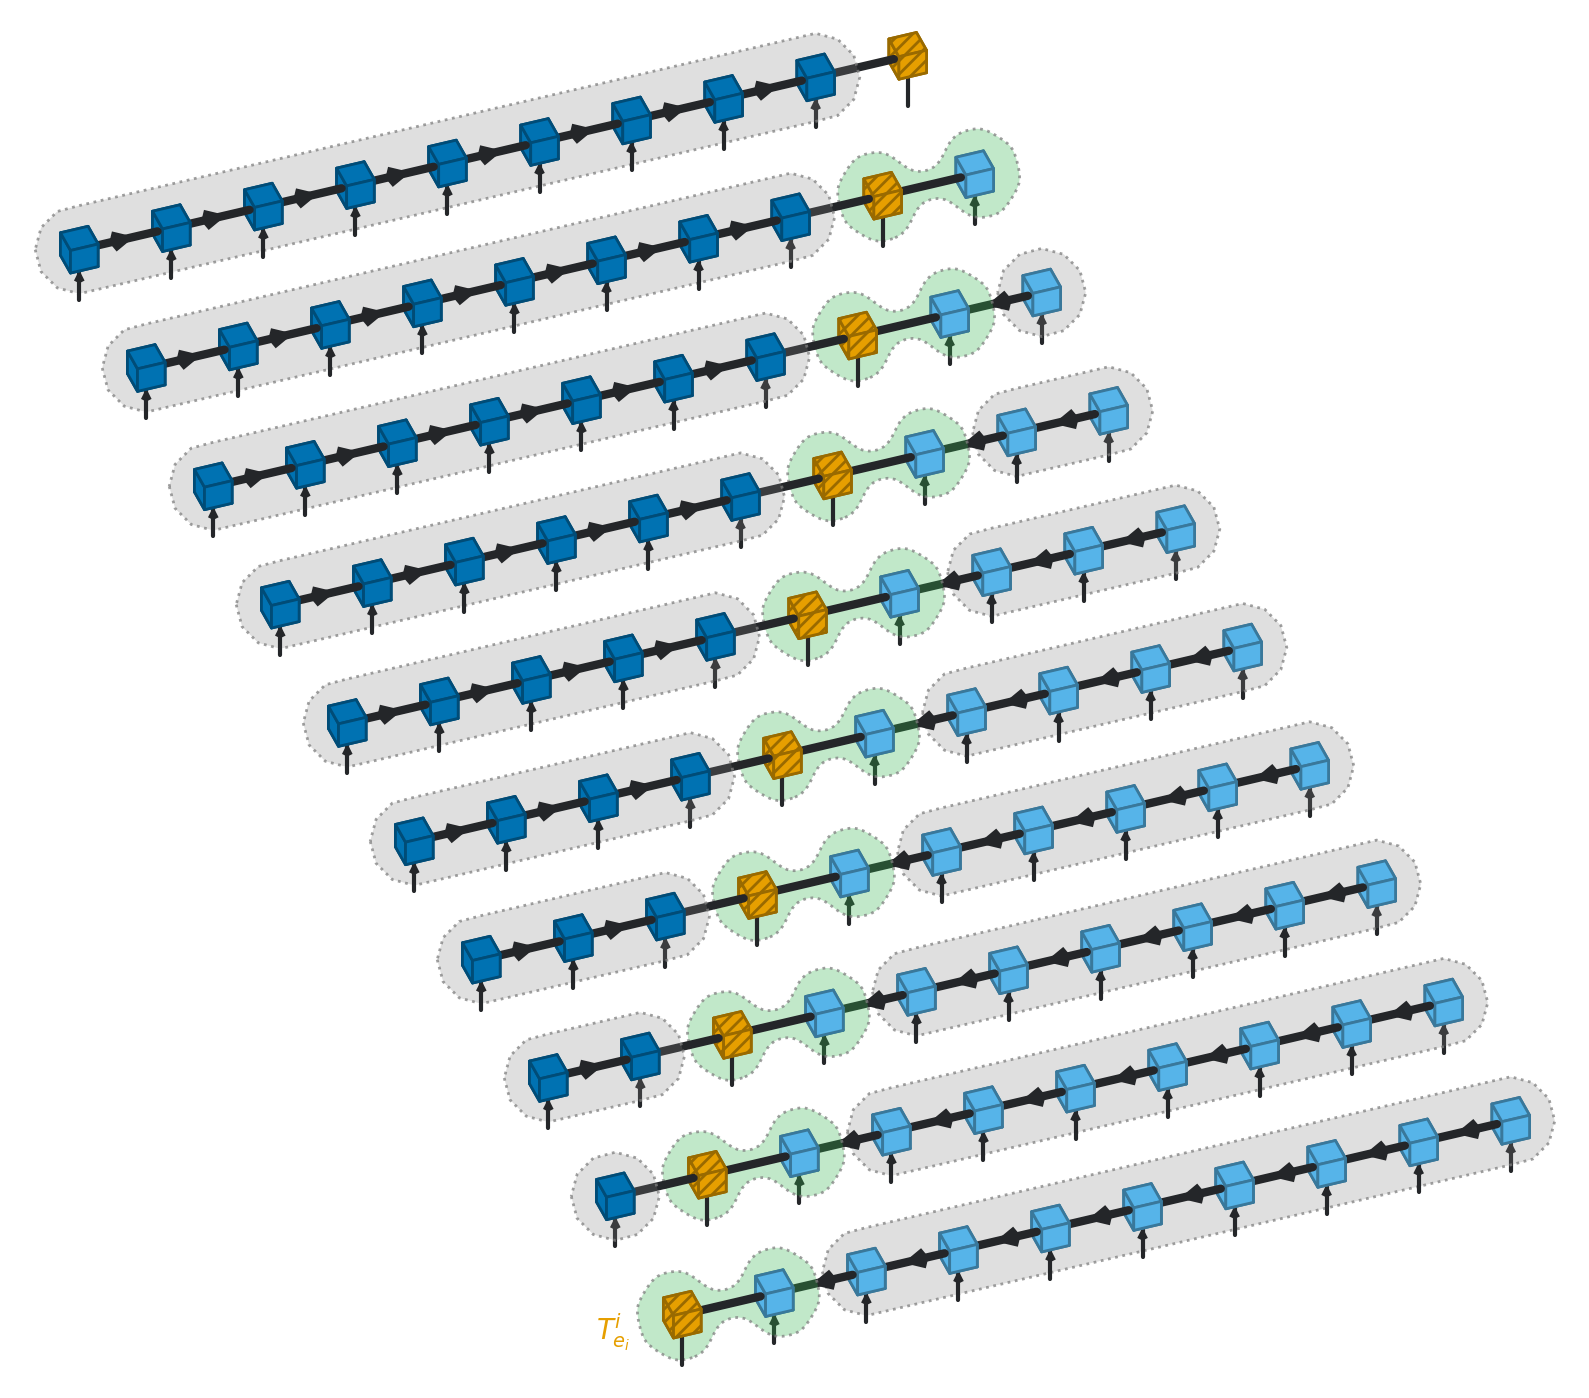

In [2]:
d = robodraw.Drawing(presets=presets, figsize=(10, 10))

L = 10

radius = 0.15

for center in range(L):
    # map the stage into a 3D x-coordinate
    x = 2 * center

    for i in range(10):
        # draw tensor, can now use cube rather than circle
        d.cube(
            (i, x, 0),
            radius=radius,
            preset=(
                "center" if i == center else "left" if i < center else "right"
            ),
        )

        # draw physical index
        d.line((i, x, 0), (i, x, -2 / 3), preset="phys")

        # draw virtual bond
        if i + 1 < L:
            d.line((i + radius, x, 0), (i + 1 - radius, x, 0), preset="bond")

        # draw isometric conditions
        if i != center:
            d.arrowhead((i, x, -2 / 3), (i, x, 0), preset="phys")
        if i < center - 1:
            d.arrowhead((i, x, 0), (i + 1, x, 0), preset="bond")
        if i > center + 1:
            d.arrowhead((i, x, 0), (i - 1, x, 0), preset="bond")

    # label the left
    if center > 0:
        d.patch_around(
            [(i, x, 0) for i in range(center)],
            radius=3 * radius,
            smoothing=0.0,
        )

    # label pair
    if center + 1 < L:
        d.patch_around_circles(
            (center, x, 0),
            2.5 * radius,
            (center + 1, x, 0),
            2.5 * radius,
            facecolor=(0.2, 0.7, 0.3, 0.3),
        )

    # label the right
    if center + 2 < L:
        d.patch_around(
            [(i, x, 0) for i in range(center + 2, L)],
            radius=3 * radius,
            smoothing=0.0,
        )

d.text((-3 / 4, 0, 0), "$T^i_{e_i}$", color=robodraw.get_color("orange"))